# 🚗 Pipeline Final Fine-tuné v2

**Détection de véhicules (YOLO) + Classification marque/modèle (EfficientNet)**

```
Image → YOLO (détection) → Crops véhicules → EfficientNet (classification) → Make/Model
```

**Modèles utilisés:**
- YOLO fine-tuné sur le dataset parking
- EfficientNet-B0 fine-tuné (33 classes make_model)

## 1. Imports et Configuration

In [1]:
# Imports standards
import torch
import torch.nn as nn
import cv2
import numpy as np
import json
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

# Modèles
from torchvision.models import efficientnet_b0
from ultralytics import YOLO

# Preprocessing
from sklearn.preprocessing import LabelEncoder
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("✅ Imports OK")

✅ Imports OK


In [6]:
# === CONFIGURATION ===

# Chemins des modèles (à adapter selon ton arborescence)
YOLO_MODEL_PATH = "/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/models/yolo_parking_finetuned/parking_detector/weights/best.pt"
EFFICIENTNET_MODEL_PATH = "/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/models/efficientnet_parking_finetuned/best_vehicle_model.pth"
LABELS_CSV_PATH = "/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Parking_labels.csv"

# Paramètres YOLO
YOLO_CONFIDENCE = 0.5
YOLO_IOU = 0.45

# Paramètres EfficientNet
IMG_SIZE = 224
NUM_CLASSES = 33

# Dossier de sortie
OUTPUT_DIR = Path("outputs/pipeline_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device (GPU si disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")

🖥️ Device: cuda


## 2. Chargement du modèle YOLO

In [7]:
# Charger YOLO fine-tuné
print(f"📦 Chargement YOLO: {YOLO_MODEL_PATH}")
yolo_model = YOLO(YOLO_MODEL_PATH)
print("✅ YOLO chargé")

📦 Chargement YOLO: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/models/yolo_parking_finetuned/parking_detector/weights/best.pt
✅ YOLO chargé


## 3. Chargement du modèle EfficientNet

In [8]:
# Charger les poids sauvegardés
print(f"📦 Chargement EfficientNet: {EFFICIENTNET_MODEL_PATH}")
state_dict = torch.load(EFFICIENTNET_MODEL_PATH, map_location=device)

# Créer le modèle avec architecture torchvision
efficientnet_model = efficientnet_b0(weights=None)

# Remplacer le classifier (33 classes, input 1280)
efficientnet_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(1280, NUM_CLASSES)
)

# Charger les poids et passer en mode évaluation
efficientnet_model.load_state_dict(state_dict)
efficientnet_model = efficientnet_model.to(device)
efficientnet_model.eval()

print(f"✅ EfficientNet chargé ({NUM_CLASSES} classes)")

📦 Chargement EfficientNet: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/models/efficientnet_parking_finetuned/best_vehicle_model.pth
✅ EfficientNet chargé (33 classes)


## 4. Chargement du Label Encoder

In [11]:
# Recréer le label encoder depuis le CSV (uniquement MAKE)
print(f"📦 Chargement labels: {LABELS_CSV_PATH}")

df = pd.read_csv(LABELS_CSV_PATH)

# Uniquement la colonne 'make'
label_encoder = LabelEncoder()
label_encoder.fit(df['make'])

print(f"✅ {len(label_encoder.classes_)} marques chargées")
print(f"\nMarques: {list(label_encoder.classes_)}")

📦 Chargement labels: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Parking_labels.csv
✅ 33 marques chargées

Marques: [' Renault', 'AUDI', 'Audi', 'BMW', 'Bentley', 'Checrolet', 'Chevrolet', 'Chrysler', 'Citroen', 'Ferrari', 'Fiat', 'Ford', 'Honda', 'Hyundai', 'Jeep', 'KIA', 'Lexus', 'Mazda', 'Mercedes', 'Mini', 'Mitsubishi', 'Nissan', 'Opel', 'Peugeot', 'Porche', 'Range rover', 'Renault', 'Smart', 'Suzuki', 'Tesla', 'Toyota', 'Toyota ', 'Volkswagen']


In [12]:
df['make'].nunique()

33

## 5. Définition des transformations

In [13]:
# Transformations pour l'inférence EfficientNet
transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

print("✅ Transformations définies")

✅ Transformations définies


## 6. Fonctions du Pipeline

In [14]:
def detect_vehicles(image):
    """
    Détecte les véhicules dans l'image avec YOLO
    
    Args:
        image: Image BGR (format OpenCV)
    
    Returns:
        Liste de dictionnaires avec bbox, confiance, classe
    """
    results = yolo_model(
        image,
        conf=YOLO_CONFIDENCE,
        iou=YOLO_IOU,
        verbose=False
    )
    
    detections = []
    
    for result in results:
        boxes = result.boxes
        if boxes is None:
            continue
        
        for i in range(len(boxes)):
            bbox = boxes.xyxy[i].cpu().numpy().astype(int)
            conf = float(boxes.conf[i].cpu().numpy())
            cls_id = int(boxes.cls[i].cpu().numpy())
            cls_name = result.names[cls_id]
            
            detections.append({
                'bbox': tuple(bbox),
                'confidence': conf,
                'class_id': cls_id,
                'class_name': cls_name
            })
    
    return detections

print("✅ Fonction detect_vehicles définie")

✅ Fonction detect_vehicles définie


In [15]:
def classify_vehicle(crop):
    """
    Classifie un crop de véhicule avec EfficientNet
    
    Args:
        crop: Image BGR du véhicule
    
    Returns:
        Dictionnaire avec make_model, confiance, top5
    """
    # BGR → RGB
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    
    # Appliquer les transformations
    transformed = transform(image=crop_rgb)
    tensor = transformed['image'].unsqueeze(0).to(device)
    
    # Inférence
    with torch.no_grad():
        output = efficientnet_model(tensor)
        probs = torch.softmax(output, dim=1)
        top5_probs, top5_indices = torch.topk(probs, k=min(5, probs.shape[1]))
    
    # Décoder les classes
    top5 = []
    for i in range(len(top5_indices[0])):
        idx = top5_indices[0][i].item()
        prob = top5_probs[0][i].item()
        class_name = label_encoder.inverse_transform([idx])[0]
        top5.append((class_name, prob))
    
    return {
        'make_model': top5[0][0],
        'confidence': top5[0][1],
        'top5': top5
    }

print("✅ Fonction classify_vehicle définie")

✅ Fonction classify_vehicle définie


In [16]:
def process_image(image_path, save_output=True):
    """
    Pipeline complet: détection + classification
    
    Args:
        image_path: Chemin vers l'image
        save_output: Sauvegarder les résultats (image + JSON)
    
    Returns:
        Dictionnaire avec tous les résultats
    """
    import time
    start = time.time()
    
    # Charger l'image
    image_path = Path(image_path)
    image = cv2.imread(str(image_path))
    
    if image is None:
        raise ValueError(f"Impossible de lire: {image_path}")
    
    print(f"\n🔍 Traitement: {image_path.name}")
    
    # 1. Détection YOLO
    detections = detect_vehicles(image)
    print(f"   📦 {len(detections)} véhicule(s) détecté(s)")
    
    # 2. Classification de chaque véhicule
    results = []
    
    for i, det in enumerate(detections):
        x1, y1, x2, y2 = det['bbox']
        crop = image[y1:y2, x1:x2]
        
        if crop.size == 0:
            continue
        
        # Classification
        classification = classify_vehicle(crop)
        
        results.append({
            'detection': det,
            'classification': classification
        })
        
        print(f"   🚗 Véhicule {i+1}: {classification['make_model']} ({classification['confidence']:.1%})")
    
    # 3. Visualisation
    vis_image = create_visualization(image, results)
    
    # 4. Sauvegarder si demandé
    if save_output:
        # Image annotée
        output_img = OUTPUT_DIR / f"{image_path.stem}_result.jpg"
        cv2.imwrite(str(output_img), vis_image)
        
        # JSON
        output_json = OUTPUT_DIR / f"{image_path.stem}_result.json"
        save_json(results, image_path, output_json)
        
        print(f"   💾 Sauvegardé: {output_img.name}")
    
    # Temps de traitement
    elapsed = (time.time() - start) * 1000
    print(f"   ⏱️ Temps: {elapsed:.1f}ms")
    
    return {
        'image_path': str(image_path),
        'num_vehicles': len(results),
        'vehicles': results,
        'visualization': vis_image,
        'processing_time_ms': elapsed
    }

print("✅ Fonction process_image définie")

✅ Fonction process_image définie


In [17]:
def create_visualization(image, results):
    """
    Crée une image annotée avec les détections
    """
    vis = image.copy()
    
    for i, res in enumerate(results):
        x1, y1, x2, y2 = res['detection']['bbox']
        conf = res['classification']['confidence']
        make_model = res['classification']['make_model'].replace('_', ' ')
        
        # Couleur selon la confiance
        if conf > 0.7:
            color = (0, 255, 0)    # Vert
        elif conf > 0.4:
            color = (0, 165, 255)  # Orange
        else:
            color = (0, 0, 255)    # Rouge
        
        # Rectangle
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        
        # Label
        label = f"{make_model} ({conf:.0%})"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(vis, (x1, y1 - th - 10), (x1 + tw + 10, y1), color, -1)
        cv2.putText(vis, label, (x1 + 5, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Titre
    title = f"Detection: {len(results)} vehicule(s)"
    cv2.putText(vis, title, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    
    return vis

print("✅ Fonction create_visualization définie")

✅ Fonction create_visualization définie


In [23]:
def save_json(results, image_path, output_path):
    """
    Sauvegarde les résultats en JSON
    """
    data = {
        'image_path': str(image_path),
        'timestamp': datetime.now().isoformat(),
        'num_vehicles': len(results),
        'vehicles': []
    }
    
    for res in results:
        vehicle = {
            'detection': {
                'bbox': [int(x) for x in res['detection']['bbox']],  # Convertir en int Python
                'confidence': float(res['detection']['confidence']),  # Convertir en float Python
                'class': str(res['detection']['class_name'])
            },
            'classification': {
                'make': res['classification']['make_model'],
                'confidence': float(res['classification']['confidence']),  # Convertir en float Python
                'top5': [
                    {'class': str(c), 'confidence': float(p)}  # Convertir en types Python natifs
                    for c, p in res['classification']['top5']
                ]
            }
        }
        data['vehicles'].append(vehicle)
    
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

print("✅ Fonction save_json définie")

✅ Fonction save_json définie


In [24]:
def show_result(result):
    """
    Affiche le résultat avec matplotlib
    """
    # Convertir BGR → RGB pour matplotlib
    img_rgb = cv2.cvtColor(result['visualization'], cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(14, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Résultat: {result['num_vehicles']} véhicule(s) détecté(s)")
    plt.show()
    
    # Résumé textuel
    print("\n" + "="*50)
    print("📊 RÉSUMÉ")
    print("="*50)
    
    for i, v in enumerate(result['vehicles']):
        print(f"\n🚗 Véhicule {i+1}:")
        print(f"   Make/Model: {v['classification']['make_model']}")
        print(f"   Confiance: {v['classification']['confidence']:.1%}")
        print(f"   Top 3:")
        for cls, prob in v['classification']['top5'][:3]:
            print(f"      - {cls}: {prob:.1%}")

print("✅ Fonction show_result définie")

✅ Fonction show_result définie


## 7. Test du Pipeline

**Modifie le chemin de l'image ci-dessous pour tester:**

In [26]:
from pathlib import Path

IMAGE_PATH = "/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/parking_vehicles/valid/images/CarLongPlate3_jp.rf.6346951cd89ffcfab32f00d76663df2a.jpg"

p = Path(IMAGE_PATH)

print(f"Existe: {p.exists()}")
print(f"Est un fichier: {p.is_file()}")

# Vérifier le dossier parent
print(f"\nDossier parent existe: {p.parent.exists()}")

# Lister les fichiers dans le dossier
if p.parent.exists():
    print(f"\nFichiers dans le dossier:")
    for f in list(p.parent.glob("*.jpg"))[:5]:
        print(f"  {f.name}")

Existe: False
Est un fichier: False

Dossier parent existe: True

Fichiers dans le dossier:
  00847_jpg.rf.dd9654ddc8e6967b5a5a6779ee7ad90b.jpg
  00870_jpg.rf.fdf996dee4c6ef3f701221f222128bf0.jpg
  00895_jpg.rf.89531722d9b44958b41612ff5c195ff3.jpg
  01071_jpg.rf.62f141529f04e7ab17092a7e04ea570b.jpg
  BMWM5_jpg.rf.5eda3dad2e629f7e01820cbce49129a9.jpg



🔍 Traitement: CarLongPlate39_jpg.rf.e3893dc454a725ea0b745a3a7395f466.jpg
   📦 1 véhicule(s) détecté(s)
   🚗 Véhicule 1: Hyundai (22.9%)
   💾 Sauvegardé: CarLongPlate39_jpg.rf.e3893dc454a725ea0b745a3a7395f466_result.jpg
   ⏱️ Temps: 102.0ms


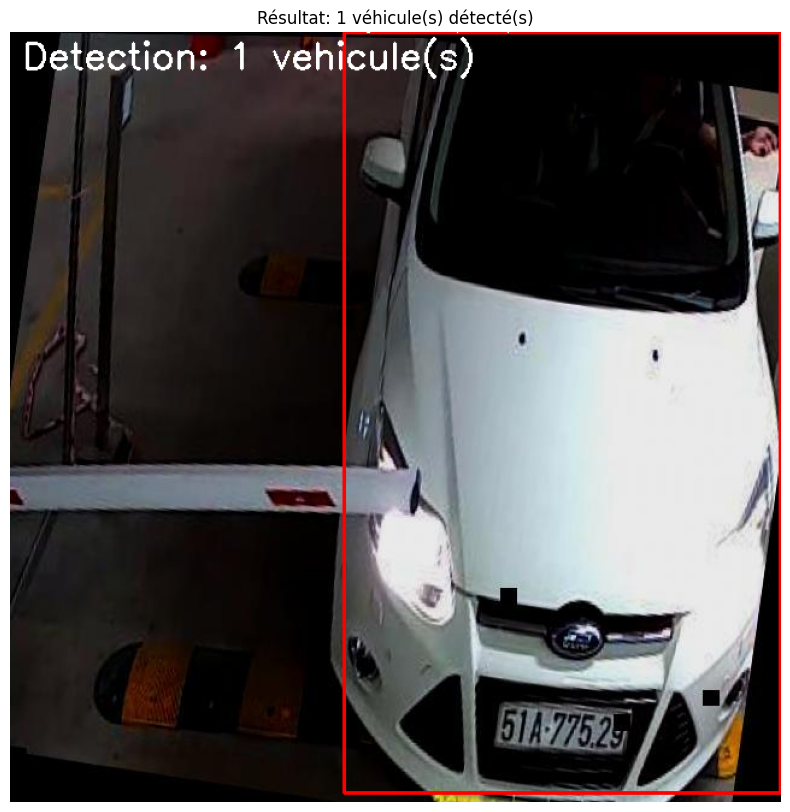


📊 RÉSUMÉ

🚗 Véhicule 1:
   Make/Model: Hyundai
   Confiance: 22.9%
   Top 3:
      - Hyundai: 22.9%
      - Ford: 20.9%
      - KIA: 6.2%


In [30]:
# === CHEMIN DE L'IMAGE À TESTER ===
IMAGE_PATH = "/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/parking_vehicles/train/images/CarLongPlate39_jpg.rf.e3893dc454a725ea0b745a3a7395f466.jpg"  # <-- MODIFIE ICI

# Lancer le pipeline
result = process_image(IMAGE_PATH)

# Afficher le résultat
show_result(result)

## 8. Test sur plusieurs images (optionnel)

In [ ]:
# Pour tester sur un dossier d'images
# IMAGES_DIR = Path("chemin/vers/dossier/images")
# 
# for img_path in IMAGES_DIR.glob("*.jpg"):
#     result = process_image(img_path)
#     show_result(result)

---

## 📋 Résumé

**Ce pipeline:**
1. Charge une image
2. Détecte les véhicules avec YOLO fine-tuné
3. Extrait les crops de chaque véhicule
4. Classifie chaque crop avec EfficientNet (make/model)
5. Génère une visualisation annotée
6. Sauvegarde les résultats (image + JSON)

**Outputs:**
- `outputs/pipeline_results/{image}_result.jpg` — Image annotée
- `outputs/pipeline_results/{image}_result.json` — Résultats JSON